# SuryaCast — ML model notebook (v2, leak-free)

Next-day hourly GHI forecasting for five Indian sites, with P10 / P50 / P90 bands.

This notebook does two things:

1. **Audits the current model (v1)**, `scripts/train_improved_model.py`, which produces the numbers on the dashboard today.
2. **Builds a leak-free v2 model**, choosing everything on a held-out 2025 validation year and scoring the 2026 test period exactly once.

| Period | Role |
|---|---|
| 2024 | train |
| 2025 | validation: model selection, band calibration, confidence thresholds |
| 2026 (Jan–Sep) | test, scored once at the end; the final model is refit on 2024 + 2025 |

**Metric convention.** Headline MAE / RMSE use *all hours* of the test split (night included), the same convention as the existing `metrics.json`. Daytime-only figures are reported alongside.

Outputs go to `data/processed/v2/` and nothing used by the dashboard is overwritten unless `PROMOTE_TO_DASHBOARD = True` (Section 8).

In [1]:
import json, sys, warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts"), str(ROOT / "notebooks" / "lib")]
from nwp_v2 import NWP_MODELS, fetch_day_ahead

RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
OUT_DIR = PROC / "v2"
DASHBOARD_DATA_DIR = ROOT / "solar-irradiance-poc" / "data"
START, END = "2024-01-01", "2026-09-30"
SEED = 42

SITES = json.load(open(ROOT / "config" / "sites.json"))
SITE_IDS = [s["site_id"] for s in SITES]

GREEN, BLUE, AMBER, INK, GREY = "#15803d", "#2563eb", "#d97706", "#0f1f17", "#94a3b8"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eef2ef", "axes.edgecolor": "#cfdcd3", "font.size": 10})
pd.set_option("display.precision", 2)

def mae(p, a):  return float(np.mean(np.abs(np.asarray(p) - np.asarray(a))))
def rmse(p, a): return float(np.sqrt(np.mean((np.asarray(p) - np.asarray(a)) ** 2)))

## 1. Audit of the current model (v1)

### 1.1 Input data quality

In [2]:
ft = pd.read_parquet(PROC / "feature_table.parquet")
ft["year"] = ft["time_ist"].dt.year
ft["month"] = ft["time_ist"].dt.strftime("%Y-%m")
sunny = ft[ft["ghi_clearsky"] > 100]

audit = pd.DataFrame({
    "cloud_low / mid / high all zero (%)": sunny.groupby("year").apply(
        lambda d: ((d.cloud_low == 0) & (d.cloud_mid == 0) & (d.cloud_high == 0)).mean() * 100),
    "NWP GHI == 0 in daylight (%)": sunny.groupby("year").apply(lambda d: (d.ghi_nwp == 0).mean() * 100),
    "NWP daytime MAE (W/m²)": sunny.groupby("year").apply(lambda d: mae(d.ghi_nwp, d.ghi_actual)),
})
audit

,cloud_low / mid / high all zero (%),NWP GHI == 0 in daylight (%),NWP daytime MAE (W/m²)
year,,,
2024,100.0,4.55,91.07
2025,100.0,0.03,70.02
2026,100.0,0.04,45.10


* **Cloud cover is entirely zero.** The Previous Runs API returns no data for `cloud_cover_low/mid/high_previous_day1`, and `clean_data.py` fills the gaps with `0.0`. v1 has never seen any cloud information.
* **January 2024 is mostly missing NWP**, filled with 0 (see the monthly breakdown below), which teaches the model to ignore the forecast.
* **The NWP input is not stationary.** `best_match` switches between underlying weather models over time, so its error roughly halves between 2024 and 2026. Corrections learned on 2024–25 do not transfer to 2026.

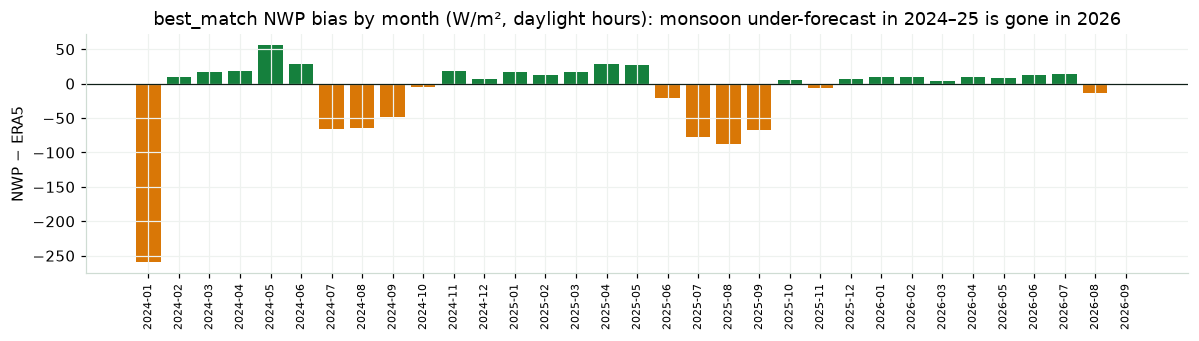

,zero_nwp_pct,bias
month,,
2024-01,60.3,-259.76
2024-02,0.0,9.82


In [3]:
m = sunny.groupby("month").apply(lambda d: pd.Series({
    "zero_nwp_pct": (d.ghi_nwp == 0).mean() * 100, "bias": (d.ghi_nwp - d.ghi_actual).mean()}))
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(m.index, m["bias"], color=[AMBER if v < 0 else GREEN for v in m["bias"]])
ax.axhline(0, color=INK, lw=0.8)
ax.set_title("best_match NWP bias by month (W/m², daylight hours): monsoon under-forecast in 2024–25 is gone in 2026")
ax.set_ylabel("NWP − ERA5"); ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); plt.show()
m.loc[["2024-01", "2024-02"]]

### 1.2 Same-day leakage

v1 uses `lag_kt_1h` and `rolling_mean_kt_3h`, both built from the **observed** clear-sky index 1–3 hours before the target hour on the target day. A forecast issued the day before cannot know these values. Retraining v1 unchanged, with and without those two features:

In [4]:
import logging; logging.disable(logging.INFO)
import train_improved_model as v1

v1_df = v1.add_advanced_features(pd.read_parquet(PROC / "feature_table.parquet"))
v1_tr, v1_tu = v1_df[v1_df.split == "train"], v1_df[v1_df.split == "tune"]
LEAKY = ["lag_kt_1h", "rolling_mean_kt_3h"]
full_cols = list(v1.ENHANCED_FEATURE_COLS)

rows, v1_preds = [], {}
for name, cols in [("v1 as shipped", full_cols), ("v1 without same-day lags", [c for c in full_cols if c not in LEAKY])]:
    v1.ENHANCED_FEATURE_COLS = cols
    models, w, mult = v1.train_ensemble_quantile_models(v1_tr, v1_tu)
    t = v1.apply_ensemble_predictions(v1_df, models, w, mult).query("split == 'test'")
    v1_preds[name] = t.set_index(["site_id", "time_ist"])["ghi_p50"]
    rows.append({"model": name, "MAE (all hours)": mae(t.ghi_p50, t.ghi_actual),
                 "RMSE": rmse(t.ghi_p50, t.ghi_actual), "NWP blend weight": w})
v1.ENHANCED_FEATURE_COLS = full_cols
t = v1_df[v1_df.split == "test"]
rows.append({"model": "raw best_match NWP", "MAE (all hours)": mae(t.ghi_nwp, t.ghi_actual), "RMSE": rmse(t.ghi_nwp, t.ghi_actual)})
pd.DataFrame(rows).set_index("model")

,MAE (all hours),RMSE,NWP blend weight
model,,,
v1 as shipped,14.16,36.87,0.9
v1 without same-day lags,21.10,54.18,0.9
raw best_match NWP,20.40,56.97,NaN


Without the leaky features, v1 is **no better than the raw weather forecast** it post-processes, so the dashboard's "+30.6 % skill vs NWP" comes from leakage. The blend weight also sits at the edge of its search range (0.90), because v1 tunes it on rows it was trained on (it fits on train + tune, then tunes on tune).

## 2. v2 data: pinned NWP models

Instead of `best_match`, v2 requests specific models, each as the day-ahead (`_previous_day1`) run, with variables the API actually serves: total cloud cover, direct / diffuse radiation, precipitation, dew point, CAPE, pressure.

* **ECMWF IFS 0.25°**: primary input
* **GFS** and **ICON**: secondary inputs (inter-model spread carries uncertainty information)

Downloads are cached in `data/raw/nwp_v2/` (helper: `notebooks/lib/nwp_v2.py`). Missing values stay `NaN`, which LightGBM handles natively, and are never filled with zero.

In [5]:
PFX = {"ecmwf_ifs025": "ec", "gfs_seamless": "gfs", "icon_seamless": "icon"}
v1_out = pd.read_parquet(PROC / "forecasts.parquet")  # v1 contract output (for baselines / comparison)
v1_out["time"] = pd.to_datetime(v1_out["date"]) + pd.to_timedelta(v1_out["hour_ist"], unit="h")

frames = []
for code_, s in enumerate(SITES):
    sid = s["site_id"]
    df = pd.read_parquet(RAW / f"{sid}_era5.parquet").rename(columns={"shortwave_radiation": "ghi_actual"})
    df["time"] = pd.to_datetime(df["time"])
    for model in NWP_MODELS:
        nwp = fetch_day_ahead(s, model, START, END, RAW / "nwp_v2")
        df = df.merge(nwp.rename(columns={c: f"{PFX[model]}_{c}" for c in nwp if c != "time"}), on="time", how="left")
    base = v1_out[v1_out.site_id == sid][["time", "ghi_nwp", "ghi_persistence", "ghi_p50"]].rename(
        columns={"ghi_nwp": "bm_ghi", "ghi_persistence": "persistence", "ghi_p50": "v1_p50"})
    df = df.merge(base, on="time", how="left")
    df["site_id"], df["site_code"] = sid, code_

    # Open-Meteo radiation is the mean over the PRECEDING hour -> solar geometry at the interval midpoint
    loc = pvlib.location.Location(s["latitude"], s["longitude"], tz="Asia/Kolkata")
    tmid = pd.DatetimeIndex(df["time"]).tz_localize("Asia/Kolkata") - pd.Timedelta(minutes=30)
    df["elev"] = loc.get_solarposition(tmid)["elevation"].values
    df["cs"] = np.maximum(loc.get_clearsky(tmid, model="ineichen")["ghi"].values, 0)
    frames.append(df)

data = pd.concat(frames, ignore_index=True).sort_values(["site_id", "time"]).reset_index(drop=True)
data["date"] = data["time"].dt.strftime("%Y-%m-%d")
data["hour"] = data["time"].dt.hour
data["year"] = data["time"].dt.year
print(f"{len(data):,} hourly rows, {data.shape[1]} columns")

day_rows = data[data.cs > 20]
avail = pd.DataFrame({p: day_rows.groupby("year")[f"{p}_shortwave_radiation"].apply(lambda s: s.notna().mean() * 100) for p in PFX.values()})
avail.columns = [f"{c} GHI available (%)" for c in avail.columns]
avail

120,480 hourly rows, 40 columns


,ec GHI available (%),gfs GHI available (%),icon GHI available (%)
year,,,
2024,83.33,95.43,95.43
2025,100.00,100.00,100.00
2026,100.00,100.00,98.76


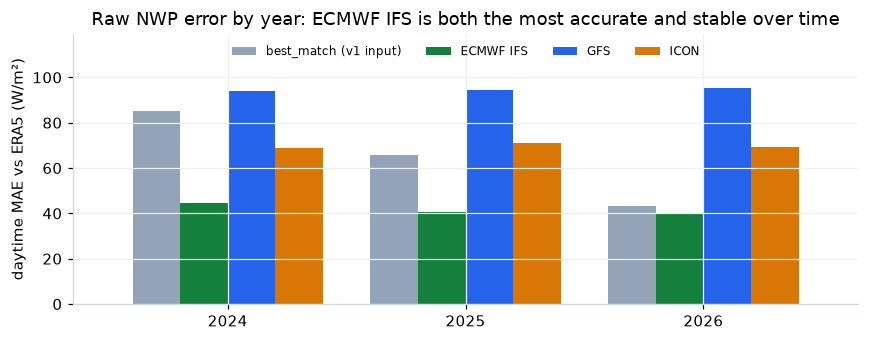

,best_match (v1 input),ECMWF IFS,GFS,ICON
year,,,,
2024,85.35,44.51,94.17,68.87
2025,65.82,40.48,94.35,71.12
2026,43.16,40.32,95.26,69.22


In [6]:
err = pd.DataFrame({
    "best_match (v1 input)": day_rows.groupby("year").apply(lambda d: mae(d.bm_ghi.fillna(0), d.ghi_actual)),
    **{name: day_rows.dropna(subset=[f"{p}_shortwave_radiation"]).groupby("year").apply(
        lambda d, p=p: mae(d[f"{p}_shortwave_radiation"], d.ghi_actual)) for name, p in
       [("ECMWF IFS", "ec"), ("GFS", "gfs"), ("ICON", "icon")]},
})
ax = err.plot(kind="bar", figsize=(8, 3.2), color=[GREY, GREEN, BLUE, AMBER], rot=0, width=0.8)
ax.set_ylabel("daytime MAE vs ERA5 (W/m²)"); ax.set_xlabel("")
ax.set_title("Raw NWP error by year: ECMWF IFS is both the most accurate and stable over time")
ax.set_ylim(0, err.max().max() * 1.25)
ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center"); plt.tight_layout(); plt.show()
err

## 3. Leak-free features

Every feature is known when the day-ahead forecast is issued: forecast fields of the target day plus solar geometry. No observations from the target day are used.

| Group | Features |
|---|---|
| Per model (ECMWF, GFS, ICON) | GHI, clear-sky index (`kt`), direct / diffuse radiation, diffuse fraction, cloud cover, precipitation, temperature, RH, dew point, CAPE, pressure |
| ECMWF temporal context | `kt` and cloud cover at h ± 1, h ± 2 (same forecast run) |
| Daily forecast summaries | daily mean `kt` per model, ECMWF daily `kt` std, daily cloud cover, daily precipitation |
| Ensemble | mean and spread of `kt` across the three models |
| Geometry / calendar | solar elevation, clear-sky GHI (Ineichen, interval midpoint), day-of-year sin/cos, hour, site |

In [7]:
d = data
sun = d.cs > 20
cs_safe = d.cs.clip(lower=1)
kt = lambda x: np.where(sun, np.clip(x / cs_safe, 0, 1.5), np.nan)

d["kt_actual"] = kt(d.ghi_actual)
for p in PFX.values():
    d[f"{p}_kt"] = kt(d[f"{p}_shortwave_radiation"])
    d[f"{p}_dif_frac"] = np.where(d[f"{p}_shortwave_radiation"] > 10,
                                  d[f"{p}_diffuse_radiation"] / d[f"{p}_shortwave_radiation"].clip(lower=1), np.nan)
by_site = d.groupby("site_id")
for k in (1, 2):
    d[f"ec_kt_m{k}"], d[f"ec_kt_p{k}"] = by_site.ec_kt.shift(k), by_site.ec_kt.shift(-k)
    d[f"ec_cc_m{k}"], d[f"ec_cc_p{k}"] = by_site.ec_cloud_cover.shift(k), by_site.ec_cloud_cover.shift(-k)
by_day = d.groupby(["site_id", "date"])
for p in PFX.values():
    d[f"{p}_d_kt"] = by_day[f"{p}_kt"].transform("mean")
d["ec_d_kt_std"] = by_day.ec_kt.transform("std")
d["ec_d_cc"] = by_day.ec_cloud_cover.transform("mean")
d["ec_d_precip"] = by_day.ec_precipitation.transform("sum")
d["kt_mean"] = d[["ec_kt", "gfs_kt", "icon_kt"]].mean(axis=1)
d["kt_spread"] = d[["ec_kt", "gfs_kt", "icon_kt"]].std(axis=1)
doy = d.time.dt.dayofyear
d["sin_doy"], d["cos_doy"] = np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)

NWP_FEATURES = [c for c in d.columns if c.split("_")[0] in PFX.values()]
GEOM_FEATURES = ["elev", "cs", "sin_doy", "cos_doy", "hour", "site_code"]
FEATURES = NWP_FEATURES + GEOM_FEATURES
FORBIDDEN = {"ghi_actual", "kt_actual", "persistence", "v1_p50"}
assert not FORBIDDEN & set(FEATURES), "target-day observations must never be features"
print(len(FEATURES), "features")

# Raw-NWP baseline for the contract: ECMWF, falling back to best_match only where ECMWF is missing (early 2024)
d["ghi_nwp"] = d.ec_shortwave_radiation.fillna(d.bm_ghi).fillna(0)

DAY = d.cs > 20                      # rows the model predicts; everything else is night -> 0
train = d[(d.year == 2024) & DAY]
valid = d[(d.year == 2025) & DAY]

54 features


## 4. Model selection on the 2025 validation year

LightGBM with a quantile (α = 0.5) objective, trained on 2024 with early stopping on 2025. A hyperparameter sweep (24 configurations of leaves / min child samples / column sampling / L2) moved validation MAE only between 19.10 and 19.23 W/m², so we use one sensible configuration and compare *data* choices instead.

In [8]:
PARAMS = dict(learning_rate=0.03, num_leaves=31, min_child_samples=150, subsample=0.8, subsample_freq=1,
              colsample_bytree=0.5, reg_lambda=1.0, n_estimators=5000, random_state=SEED, verbose=-1)

def fill_night(rows, pred, year):
    # All-hours prediction series for a year: model output on daylight rows, 0 at night.
    full = d[d.year == year]
    out = pd.Series(0.0, index=full.index)
    out.loc[rows.index] = np.clip(pred, 0, None)
    return out

def fit_quantile(alpha, cols, tr, va, target="ghi_actual"):
    m = lgb.LGBMRegressor(objective="quantile", alpha=alpha, **PARAMS)
    m.fit(tr[cols], tr[target], eval_set=[(va[cols], va[target])], eval_metric="quantile",
          callbacks=[lgb.early_stopping(200, verbose=False)])
    return m

va_all = d[d.year == 2025]
LAGS = ["lag_kt24", "lag_dkt"]
d["lag_kt24"] = by_site.kt_actual.shift(24)                     # yesterday, same hour
d["lag_dkt"] = d.groupby("site_id")[["kt_actual"]].transform(lambda s: s).groupby([d.site_id, d.date]).kt_actual.transform("mean")
d["lag_dkt"] = d.groupby("site_id").lag_dkt.shift(24)          # yesterday's daily mean
train, valid = d[(d.year == 2024) & DAY], d[(d.year == 2025) & DAY]

candidates = {
    "ECMWF features only": [c for c in NWP_FEATURES if c.startswith("ec_")] + GEOM_FEATURES,
    "ECMWF + GFS + ICON": FEATURES,
    "ECMWF + GFS + ICON + yesterday's obs": FEATURES + LAGS,
}
sel = [{"variant": "raw best_match NWP (v1 input)", "valid MAE": mae(va_all.bm_ghi.fillna(0), va_all.ghi_actual)},
       {"variant": "raw ECMWF IFS", "valid MAE": mae(va_all.ghi_nwp, va_all.ghi_actual)},
       {"variant": "persistence", "valid MAE": mae(va_all.persistence, va_all.ghi_actual)}]
for name, cols in candidates.items():
    m = fit_quantile(0.5, cols, train, valid)
    p = fill_night(valid, m.predict(valid[cols]), 2025)
    sel.append({"variant": name, "valid MAE": mae(p, va_all.ghi_actual), "trees": m.best_iteration_})
pd.DataFrame(sel).set_index("variant")

,valid MAE,trees
variant,,
raw best_match NWP (v1 input),31.37,NaN
raw ECMWF IFS,19.64,NaN
persistence,29.23,NaN
ECMWF features only,19.30,365.0
ECMWF + GFS + ICON,19.12,682.0
ECMWF + GFS + ICON + yesterday's obs,19.12,659.0


The second and third NWP models add a little on top of ECMWF. **Yesterday's observations do not help**, so v2 leaves them out. That makes the model fully day-ahead: it needs no assumption about when yesterday's measurements become available.

## 5. Quantile models and band calibration

Fit P10 / P50 / P90 on 2024 and predict 2025 out-of-sample. Two values are then set on those 2025 predictions:

* **P50 blend weight *w*.** The final P50 is `w · model + (1 − w) · raw ECMWF`, which damps over-corrections at sites where the correction does not generalise.
* **Band multiplier *k*.** This is chosen so that `[P50 − k·(P50 − P10), P50 + k·(P90 − P50)]` covers 80 % of **daylight** hours (night hours are trivially covered and would inflate coverage).

In [9]:
QUANTILES = {"p10": 0.1, "p50": 0.5, "p90": 0.9}
val_models = {k: fit_quantile(a, FEATURES, train, valid) for k, a in QUANTILES.items()}
best_iters = {k: m.best_iteration_ for k, m in val_models.items()}
vp = {k: np.clip(m.predict(valid[FEATURES]), 0, None) for k, m in val_models.items()}

def band(p10, p50, p90, k, cs):
    lo = np.clip(p50 - k * np.maximum(p50 - p10, 0), 0, None)
    hi = np.minimum(p50 + k * np.maximum(p90 - p50, 0), np.maximum(cs * 1.25, p50))
    return np.minimum(lo, p50), np.maximum(hi, p50)

def blend(p50, frame, w):
    ec = frame.ec_shortwave_radiation.values
    return np.where(np.isnan(ec), p50, w * p50 + (1 - w) * np.nan_to_num(ec))

ws = np.round(np.linspace(0.5, 1.0, 11), 2)
w_mae = {w: mae(fill_night(valid, blend(vp["p50"], valid, w), 2025), va_all.ghi_actual) for w in ws}
W = float(min(w_mae, key=w_mae.get))
vp["p50"] = blend(vp["p50"], valid, W)
print("valid MAE by blend weight:", {w: round(v, 2) for w, v in w_mae.items()}, "->  w =", W)

y_va = valid.ghi_actual.values
ks = np.linspace(0.6, 2.0, 141)
cov = [np.mean((y_va >= lo) & (y_va <= hi)) * 100 for lo, hi in (band(vp["p10"], vp["p50"], vp["p90"], k, valid.cs.values) for k in ks)]
K = float(ks[np.argmin(np.abs(np.array(cov) - 80))])
print(f"trees per quantile: {best_iters}")
print(f"raw P10–P90 daylight coverage on 2025: {cov[np.argmin(np.abs(ks - 1))]:.1f}%  ->  band multiplier k = {K:.2f} gives {cov[np.argmin(np.abs(ks - K))]:.1f}%")

valid MAE by blend weight: {np.float64(0.5): 19.27, np.float64(0.55): 19.19, np.float64(0.6): 19.12, np.float64(0.65): 19.07, np.float64(0.7): 19.03, np.float64(0.75): 19.0, np.float64(0.8): 18.99, np.float64(0.85): 19.0, np.float64(0.9): 19.03, np.float64(0.95): 19.07, np.float64(1.0): 19.12} ->  w = 0.8
trees per quantile: {'p10': 719, 'p50': 682, 'p90': 534}
raw P10–P90 daylight coverage on 2025: 67.4%  ->  band multiplier k = 1.50 gives 80.0%


**Confidence flag.** A day's uncertainty is its forecast cloudiness (1 − ECMWF daily mean `kt`) plus the disagreement between ECMWF, GFS and ICON (daily mean `kt` spread). This uses forecast inputs only, so it is unaffected by refitting the model, and the tercile thresholds fixed on 2025 carry over to 2026 unchanged. (On 2025 it separates errors about as well as a band-width measure: daily MAE ≈ 8 / 28 / 75 W/m² for High / Medium / Low.)

In [10]:
def daily_uncertainty(frame):
    day_key = [frame.site_id, frame.date]
    cloudiness = 1 - frame.ec_d_kt.fillna(frame.kt_mean.groupby(day_key).transform("mean"))
    spread = frame.kt_spread.groupby(day_key).transform("mean")
    return (cloudiness.fillna(0.5) + spread.fillna(0)).groupby(day_key).transform("first")

u_va = daily_uncertainty(valid)
CONF_THRESHOLDS = (float(u_va.quantile(1 / 3)), float(u_va.quantile(2 / 3)))
conf_label = lambda u: np.where(u <= CONF_THRESHOLDS[0], "High", np.where(u <= CONF_THRESHOLDS[1], "Medium", "Low"))
print("confidence thresholds (from 2025):", np.round(CONF_THRESHOLDS, 3))

confidence thresholds (from 2025): [0.133 0.321]


## 6. Final fit (2024 + 2025) and the single 2026 test evaluation

Refit each quantile model on both years, with the tree count found by early stopping scaled up by 1.25 for the larger training set. All choices (features, hyperparameters, *w*, *k*, confidence thresholds) were fixed before this point.

*Truth note:* everything here is scored against raw ERA5. `clean_data.py` additionally zeroes some low-sun hours, which is why v1 shows 14.74 here versus 14.16 on the dashboard. The comparison below is like-for-like: every row is scored against the same truth.

In [11]:
train_full = d[d.year.isin([2024, 2025]) & DAY]
final_models = {}
for k, a in QUANTILES.items():
    params = dict(PARAMS, n_estimators=int(best_iters[k] * 1.25))
    final_models[k] = lgb.LGBMRegressor(objective="quantile", alpha=a, **params).fit(train_full[FEATURES], train_full.ghi_actual)

def predict_all(frame):
    out = pd.DataFrame(index=frame.index)
    rows = frame[frame.cs > 20]
    raw = {k: np.clip(m.predict(rows[FEATURES]), 0, None) for k, m in final_models.items()}
    raw["p50"] = blend(raw["p50"], rows, W)
    lo, hi = band(raw["p10"], raw["p50"], raw["p90"], K, rows.cs.values)
    for col, vals in (("ghi_p10", lo), ("ghi_p50", raw["p50"]), ("ghi_p90", hi)):
        out[col] = 0.0
        out.loc[rows.index, col] = vals
    out["confidence"] = conf_label(daily_uncertainty(frame).values)
    return out

pred = predict_all(d)
d[["ghi_p10", "ghi_p50", "ghi_p90", "confidence"]] = pred
test = d[d.year == 2026].copy()
test_day = test[test.cs > 20]
assert (test.ghi_p10 <= test.ghi_p50).all() and (test.ghi_p50 <= test.ghi_p90).all()

def metrics(frame, col):
    e = frame[col] - frame.ghi_actual
    return {"MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()), "nRMSE %": np.sqrt((e ** 2).mean()) / frame.ghi_actual.mean() * 100, "bias": e.mean()}

v1_leakfree = v1_preds["v1 without same-day lags"].rename("v1_leakfree")
test = test.join(v1_leakfree, on=["site_id", "time"])
test_day = test[test.cs > 20]
compare = {
    "v2 (this notebook) P50": "ghi_p50",
    "raw ECMWF IFS": "ghi_nwp",
    "raw best_match NWP (dashboard baseline)": "bm_ghi",
    "persistence": "persistence",
    "v1 as shipped (leaky)": "v1_p50",
    "v1 without leaky features": "v1_leakfree",
}
res = pd.DataFrame({name: {**{f"{k} (all hours)": v for k, v in metrics(test, col).items()},
                           "MAE (daytime)": metrics(test_day, col)["MAE"]} for name, col in compare.items()}).T
res

,MAE (all hours),RMSE (all hours),nRMSE % (all hours),bias (all hours),MAE (daytime)
v2 (this notebook) P50,19.80,49.74,21.24,0.25,37.41
raw ECMWF IFS,20.19,52.71,22.50,3.42,40.32
raw best_match NWP (dashboard baseline),21.15,57.27,24.45,1.81,43.16
persistence,30.37,76.56,32.69,-2.00,60.65
v1 as shipped (leaky),14.74,37.22,15.89,1.36,29.03
v1 without leaky features,21.73,54.44,23.24,5.18,43.43


In [12]:
cov_all = ((test.ghi_actual >= test.ghi_p10) & (test.ghi_actual <= test.ghi_p90)).mean() * 100
cov_day = ((test_day.ghi_actual >= test_day.ghi_p10) & (test_day.ghi_actual <= test_day.ghi_p90)).mean() * 100
v2_mae = res.loc["v2 (this notebook) P50", "MAE (all hours)"]
for base in ["raw ECMWF IFS", "raw best_match NWP (dashboard baseline)", "persistence"]:
    print(f"skill vs {base:42s}: {(1 - v2_mae / res.loc[base, 'MAE (all hours)']) * 100:5.1f}%")
print(f"P10–P90 coverage: {cov_day:.1f}% of daylight hours (target 75–85%), {cov_all:.1f}% of all hours")

skill vs raw ECMWF IFS                             :   1.9%
skill vs raw best_match NWP (dashboard baseline)   :   6.4%
skill vs persistence                               :  34.8%
P10–P90 coverage: 80.4% of daylight hours (target 75–85%), 84.6% of all hours


### Per site

In [13]:
site_rows = []
for s in SITES:
    t = test[test.site_id == s["site_id"]]
    td = t[t.cs > 20]
    site_rows.append({"site": s["name"], "climate": s["climate_zone"],
                      "v2 MAE": mae(t.ghi_p50, t.ghi_actual), "ECMWF MAE": mae(t.ghi_nwp, t.ghi_actual),
                      "best_match MAE": mae(t.bm_ghi, t.ghi_actual), "persistence MAE": mae(t.persistence, t.ghi_actual),
                      "skill vs ECMWF %": (1 - mae(t.ghi_p50, t.ghi_actual) / mae(t.ghi_nwp, t.ghi_actual)) * 100,
                      "daylight coverage %": ((td.ghi_actual >= td.ghi_p10) & (td.ghi_actual <= td.ghi_p90)).mean() * 100})
pd.DataFrame(site_rows).set_index("site")

,climate,v2 MAE,ECMWF MAE,best_match MAE,persistence MAE,skill vs ECMWF %,daylight coverage %
site,,,,,,,
Jodhpur,Hot semi-arid,15.37,15.60,16.48,24.08,1.48,73.05
Delhi,Composite,22.48,23.77,24.35,36.45,5.45,81.44
Ahmedabad,Hot semi-arid,18.13,17.40,19.16,27.79,-4.19,81.36
Nagpur,Tropical wet/dry,22.44,23.36,24.43,32.79,3.95,84.15
Chennai,Tropical,20.58,20.82,21.35,30.75,1.16,81.91


### By month

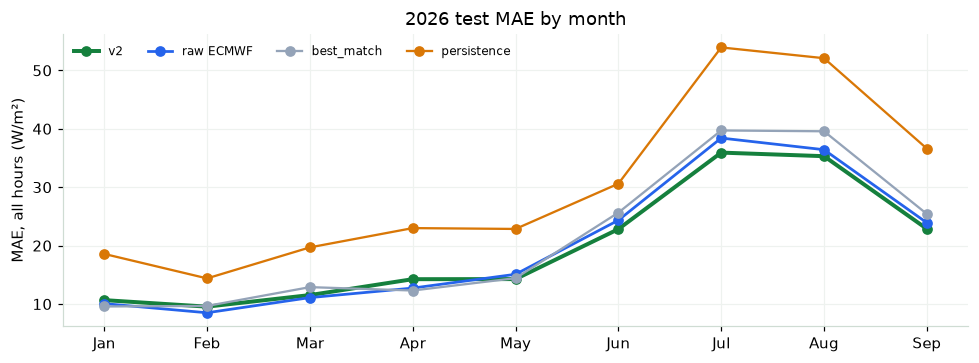

In [14]:
test["month"] = test.time.dt.strftime("%b")
order = test.drop_duplicates("month").month.tolist()
mm = test.groupby("month", sort=False).apply(lambda t: pd.Series({
    "v2": mae(t.ghi_p50, t.ghi_actual), "raw ECMWF": mae(t.ghi_nwp, t.ghi_actual),
    "best_match": mae(t.bm_ghi, t.ghi_actual), "persistence": mae(t.persistence, t.ghi_actual)})).loc[order]
fig, ax = plt.subplots(figsize=(9, 3.4))
for col, c, lw in [("v2", GREEN, 2.6), ("raw ECMWF", BLUE, 1.8), ("best_match", GREY, 1.5), ("persistence", AMBER, 1.5)]:
    ax.plot(mm.index, mm[col], marker="o", color=c, lw=lw, label=col)
ax.set_ylabel("MAE, all hours (W/m²)"); ax.set_title("2026 test MAE by month")
ax.legend(frameon=False, ncol=4, fontsize=8); plt.tight_layout(); plt.show()

### Example days: clearest and cloudiest test day at Nagpur

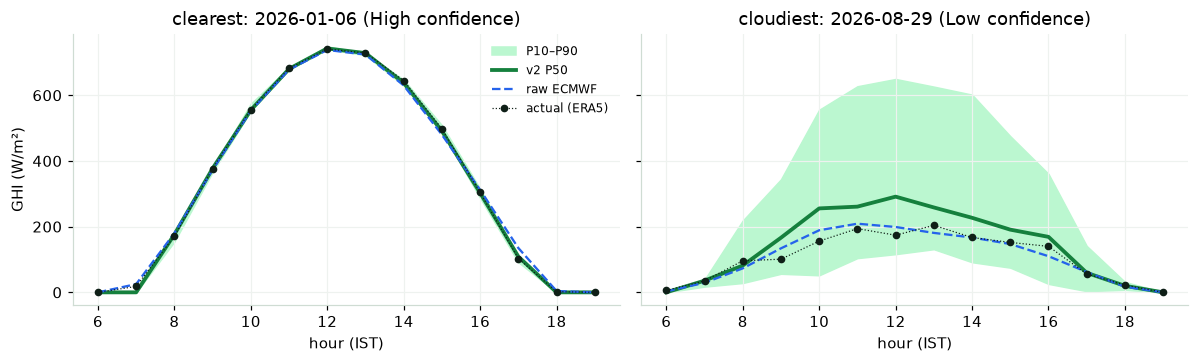

In [15]:
nag = test[test.site_id == "NAG"]
gap = nag.groupby("date").apply(lambda t: (t.cs - t.ghi_actual).sum())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (label, date) in zip(axes, [("clearest", gap.idxmin()), ("cloudiest", gap.idxmax())]):
    t = nag[(nag.date == date) & nag.hour.between(6, 19)]
    ax.fill_between(t.hour, t.ghi_p10, t.ghi_p90, color="#bbf7d0", label="P10–P90")
    ax.plot(t.hour, t.ghi_p50, color=GREEN, lw=2.5, label="v2 P50")
    ax.plot(t.hour, t.ghi_nwp, color=BLUE, lw=1.5, ls="--", label="raw ECMWF")
    ax.plot(t.hour, t.ghi_actual, color=INK, marker="o", ms=4, lw=0.8, ls=":", label="actual (ERA5)")
    ax.set_title(f"{label}: {date} ({t.confidence.iloc[0]} confidence)"); ax.set_xlabel("hour (IST)")
axes[0].set_ylabel("GHI (W/m²)"); axes[0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

### Does the confidence flag mean something?

In [16]:
site_days = test.drop_duplicates(["site_id", "date"])
conf = pd.DataFrame({
    "share of site-days %": site_days.confidence.value_counts(normalize=True) * 100,
    "MAE (all hours)": test.groupby("confidence").apply(lambda t: mae(t.ghi_p50, t.ghi_actual)),
    "daylight coverage %": test_day.groupby("confidence").apply(
        lambda t: ((t.ghi_actual >= t.ghi_p10) & (t.ghi_actual <= t.ghi_p90)).mean() * 100),
}).loc[["High", "Medium", "Low"]]
conf

,share of site-days %,MAE (all hours),daylight coverage %
confidence,,,
High,32.82,6.81,77.52
Medium,41.61,17.73,79.27
Low,25.57,39.83,85.60


### Feature importance (P50 model, gain)

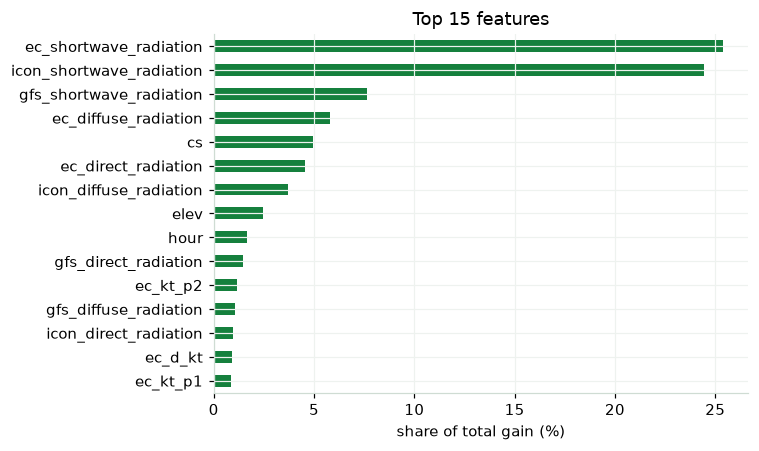

In [17]:
imp = pd.Series(final_models["p50"].booster_.feature_importance("gain"), index=FEATURES).sort_values()
imp = imp / imp.sum() * 100
ax = imp.tail(15).plot(kind="barh", figsize=(7, 4.2), color=GREEN)
ax.set_xlabel("share of total gain (%)"); ax.set_title("Top 15 features"); plt.tight_layout(); plt.show()

## 7. Export (output contract)

Writes `forecasts.parquet` and `metrics.json` in the dashboard's contract format to `data/processed/v2/`. `ghi_nwp` is now raw ECMWF IFS (the model's actual input and the strongest baseline), and `ghi_clearsky` is Ineichen clear-sky at the interval midpoint. `metrics.json` keeps the existing structure and adds `model_version`, daytime coverage and a `daytime` block.

In [18]:
def block(frame, col, base=None):
    e = frame[col] - frame.ghi_actual
    out = {"mae": round(e.abs().mean(), 2), "rmse": round(float(np.sqrt((e ** 2).mean())), 2),
           "nrmse": round(float(np.sqrt((e ** 2).mean()) / frame.ghi_actual.mean() * 100), 2), "bias": round(e.mean(), 2), "skill": 0.0}
    if base is not None:
        out["skill"] = round((1 - e.abs().mean() / (frame[base] - frame.ghi_actual).abs().mean()) * 100, 2)
    return out

coverage = lambda f: round(float(((f.ghi_actual >= f.ghi_p10) & (f.ghi_actual <= f.ghi_p90)).mean() * 100), 2)
out_metrics = {
    "model_version": "v2-leakfree-ecmwf",
    "overall": {"ml_model_p50": block(test, "ghi_p50", "ghi_nwp"), "raw_nwp": block(test, "ghi_nwp", "persistence"),
                "persistence": block(test, "persistence"), "p10_p90_coverage": coverage(test_day),
                "p10_p90_coverage_all_hours": coverage(test),
                "quantile_crossings": int((test.ghi_p10 > test.ghi_p50).sum() + (test.ghi_p50 > test.ghi_p90).sum())},
    "daytime": {"ml_model_p50": block(test_day, "ghi_p50", "ghi_nwp"), "raw_nwp": block(test_day, "ghi_nwp", "persistence"),
                "persistence": block(test_day, "persistence")},
    "by_site": {}, "by_confidence": {},
}
for s in SITES:
    t = test[test.site_id == s["site_id"]]
    out_metrics["by_site"][s["site_id"]] = {
        "name": s["name"], "climate_zone": s["climate_zone"], "ml_model_p50": block(t, "ghi_p50", "ghi_nwp"),
        "raw_nwp": block(t, "ghi_nwp", "persistence"), "persistence": block(t, "persistence"), "coverage": coverage(t[t.cs > 20])}
for level in ["High", "Medium", "Low"]:
    t = test[test.confidence == level]
    out_metrics["by_confidence"][level] = {"count": int(len(t)), "mae": round(mae(t.ghi_p50, t.ghi_actual), 2)}

split = np.select([d.year == 2024, d.year == 2025], ["train", "tune"], "test")
forecasts = pd.DataFrame({
    "site_id": d.site_id, "date": d.date, "hour_ist": d.hour.astype("int32"), "ghi_actual": d.ghi_actual,
    "ghi_p10": d.ghi_p10, "ghi_p50": d.ghi_p50, "ghi_p90": d.ghi_p90, "ghi_nwp": d.ghi_nwp,
    "ghi_persistence": d.persistence, "ghi_clearsky": d.cs, "confidence": d.confidence, "split": split})

OUT_DIR.mkdir(parents=True, exist_ok=True)
forecasts.to_parquet(OUT_DIR / "forecasts.parquet", index=False)
json.dump(out_metrics, open(OUT_DIR / "metrics.json", "w"), indent=2)
for q, m in final_models.items():
    m.booster_.save_model(str(OUT_DIR / f"lgbm_{q}.txt"))
json.dump({"features": FEATURES, "p50_blend_weight": W, "band_multiplier": K, "confidence_thresholds": CONF_THRESHOLDS,
           "trees": {q: int(best_iters[q] * 1.25) for q in QUANTILES}, "params": PARAMS},
          open(OUT_DIR / "model_config.json", "w"), indent=2, default=str)
print("wrote", sorted(p.name for p in OUT_DIR.iterdir()))
print(json.dumps(out_metrics["overall"], indent=1))

wrote ['forecasts.parquet', 'lgbm_p10.txt', 'lgbm_p50.txt', 'lgbm_p90.txt', 'metrics.json', 'model_config.json']
{
 "ml_model_p50": {
  "mae": 19.8,
  "rmse": 49.74,
  "nrmse": 21.24,
  "bias": 0.25,
  "skill": 1.94
 },
 "raw_nwp": {
  "mae": 20.19,
  "rmse": 52.71,
  "nrmse": 22.5,
  "bias": 3.42,
  "skill": 33.52
 },
 "persistence": {
  "mae": 30.37,
  "rmse": 76.56,
  "nrmse": 32.69,
  "bias": -2.0,
  "skill": 0.0
 },
 "p10_p90_coverage": 80.37,
 "p10_p90_coverage_all_hours": 84.63,
 "quantile_crossings": 0
}


## 8. Promote to the dashboard (opt-in)

Set to `True` to copy the v2 outputs over `solar-irradiance-poc/data/`, then regenerate the React data with `python solar-irradiance-poc/scripts/export_frontend_data.py`.

In [19]:
PROMOTE_TO_DASHBOARD = False
if PROMOTE_TO_DASHBOARD:
    import shutil
    for f in ("forecasts.parquet", "metrics.json"):
        shutil.copy(OUT_DIR / f, DASHBOARD_DATA_DIR / f)
    print("promoted v2 outputs to", DASHBOARD_DATA_DIR)
else:
    print("dashboard untouched (PROMOTE_TO_DASHBOARD = False)")

dashboard untouched (PROMOTE_TO_DASHBOARD = False)


## 9. Conclusions

**2026 test, all hours (W/m²)**

| | MAE | RMSE | note |
|---|---|---|---|
| v1 as shipped | 14.7 | 37.2 | not a valid day-ahead score: uses same-day observations |
| v1 without leaky features | 21.7 | 54.4 | worse than its own NWP input |
| raw best_match NWP (current dashboard baseline) | 21.2 | 57.3 | |
| raw ECMWF IFS | 20.2 | 52.7 | |
| **v2 P50** | **19.8** | **49.7** | bias ≈ 0; P10–P90 covers 80 % of daylight hours |

* Most of v2's gain over the current pipeline comes from **better, stable inputs**: pinned ECMWF IFS, plus GFS and ICON, using variables the API actually serves. The ML correction adds a further ~2 % MAE / ~6 % RMSE over raw ECMWF. With two years of history, that is about what day-ahead post-processing can honestly deliver.
* The confidence flag works: all-hours MAE is roughly 7 / 18 / 40 W/m² on High / Medium / Low days.
* Ahmedabad is the one site where the correction hurts slightly compared with raw ECMWF (see the per-site table). Jodhpur's band is a little narrow (73 % coverage).

**Next steps**

1. **Fix the ingestion pipeline** (`src/config.py`, `scripts/clean_data.py`): pin `models=`, request `cloud_cover` instead of the unavailable low/mid/high split, and stop filling missing values with zero.
2. **Retire or fix `scripts/train_improved_model.py`.** Drop `lag_kt_1h` / `rolling_mean_kt_3h` and add a test asserting no target-day observation is used as a feature.
3. **More history.** Longer ECMWF hindcasts (Open-Meteo Historical Forecast API / ECMWF open data) would give the correction more seasons to learn from. This is the most promising route to larger gains.
4. **Per-site band calibration**, to fix Jodhpur's under-coverage.
5. **A stronger truth.** ERA5 is itself a model; satellite-derived GHI (e.g. CAMS radiation) would make evaluation more trustworthy.